In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.parameters import Parameters
from src.acquisition import Acquisition
from src.forward import forward
from src.utilities import ricker_wavelet
from src.kernels import green2d

r = compute_reflectivity(h,vp,rho,omegas,p,free_surface,zr,zs)

Wrapper for ``compute_reflectivity``.

Parameters
----------
h : input rank-1 array('d') with bounds (nlay)
vp : input rank-1 array('d') with bounds (nlay)
rho : input rank-1 array('d') with bounds (nlay)
omegas : input rank-1 array('G') with bounds (nw)
p : input rank-1 array('d') with bounds (nkq)
free_surface : input int
zr : input float
zs : input float

Returns
-------
r : rank-2 array('G') with bounds (nw,nkq)



In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({
    "text.usetex": True,         # Use LaTeX
    "font.family": "serif",      # Use serif fonts
    "font.size": 18,             # Set font size
    "axes.labelsize": 18,        # Label font size
    "legend.fontsize": 18,       # Legend font size
    "xtick.labelsize": 18,       # X-axis tick size
    "ytick.labelsize": 18,       # Y-axis tick size
    "figure.figsize": (8,6),     # Set figure size
    "lines.linewidth": 1.5,        # Line thickness
    "grid.alpha": 0.5,           # Grid transparency
    "savefig.dpi": 300           # High-resolution images
})

In [4]:
layers = [
        (500.0, 1500.0, 2000.0), # top layer
        (2000.0, 4500.0, 2000.0),
        (3000.0, 3000.0, 2000.0),
        (2500.0, 3800.0, 2000.0)
    ]

In [5]:
layers = [
        (100.0, 1505.0, 2000.0), # top layer
        (200.0, 1603.0, 2000.0),
        (250.0, 1749.0, 2000.0),
        (350.0, 2019.0, 2000.0),
        (450.0, 2179.0, 2000.0),
        (550.0, 1900.0, 2000.0),
        (650.0, 2265.0, 2000.0),
        (700.0, 3281.0, 2000.0),
    ]

In [16]:
total_time = 2.    # seconds
f0 = 10.0           # Ricker central frequency (Hz)
f_max = 8.0 * f0    # practical Ricker cutoff
# Nyquist frequency for f_max
dt = 1/(2.*f_max)
print("dt =", dt)
#dt = total_time / (nt-1)
nfft = 2**int(np.ceil(np.log2(total_time/dt)))
nfft *= 4 # zero-padding to ensure late wrap-around
print("nfft =", nfft)
nt = int(total_time / dt) + 1
print("nt =", nt)
#time = np.arange(nt) * dt

param = Parameters(total_time=total_time, nt=nt, f0=f0, nfft=nfft, epsilon=0.5) # 256

# x and z positions of sources
sources = [(10.0, 76.0)]#, (580.0, 76.0), (580.0, 70.0)]
# x and z positions of receivers
Nr = 256 # 
x_receivers = np.linspace(0.0, 4000.0, Nr)
receivers = [(x, 76.0) for x in x_receivers]
print(receivers)
acq = Acquisition(sources, receivers)

dt = 0.00625
nfft = 2048
nt = 321
[(np.float64(0.0), 76.0), (np.float64(15.686274509803921), 76.0), (np.float64(31.372549019607842), 76.0), (np.float64(47.05882352941176), 76.0), (np.float64(62.745098039215684), 76.0), (np.float64(78.4313725490196), 76.0), (np.float64(94.11764705882352), 76.0), (np.float64(109.80392156862744), 76.0), (np.float64(125.49019607843137), 76.0), (np.float64(141.17647058823528), 76.0), (np.float64(156.8627450980392), 76.0), (np.float64(172.54901960784312), 76.0), (np.float64(188.23529411764704), 76.0), (np.float64(203.92156862745097), 76.0), (np.float64(219.6078431372549), 76.0), (np.float64(235.2941176470588), 76.0), (np.float64(250.98039215686273), 76.0), (np.float64(266.66666666666663), 76.0), (np.float64(282.35294117647055), 76.0), (np.float64(298.0392156862745), 76.0), (np.float64(313.7254901960784), 76.0), (np.float64(329.4117647058823), 76.0), (np.float64(345.09803921568624), 76.0), (np.float64(360.78431372549016), 76.0), (np.float64(376.4705882352941)

In [7]:
#!f2py -c -m reflectivity ../src/fortran/reflectivity.f90 --f90flags="-O3 -march=native -ffast-math -funroll-loops -fopenmp -fopenmp-simd" --opt="-O3 -march=native -ffast-math -funroll-loops -fopenmp" -lgomp

In [8]:
#from src.fortran.reflectivity_benchmark import fortran_reflectivity
#import reflectivity
#rfmod = reflectivity.reflectivity_mod 
#print(rfmod.compute_reflectivity.__doc__)

In [9]:
#!f2py -c -m filon_fort ../src/quadrature/filon_fort.f90 --f90flags="-O3 -march=native -ffast-math -funroll-loops -fopenmp -fopenmp-simd" --opt="-O3 -march=native -ffast-math -funroll-loops -fopenmp" -lgomp

In [10]:
#import filon_fort
# get_weights_filon(k0_vec, z, x, thetas, Vinv, global_idx, Weights)
#filon_mod = filon_fort.filon_mod 
#print(filon_mod.get_weights_filon.__doc__)

elapsed: 4.16 s
Fortran reflectivity elapsed time: 0.36 s


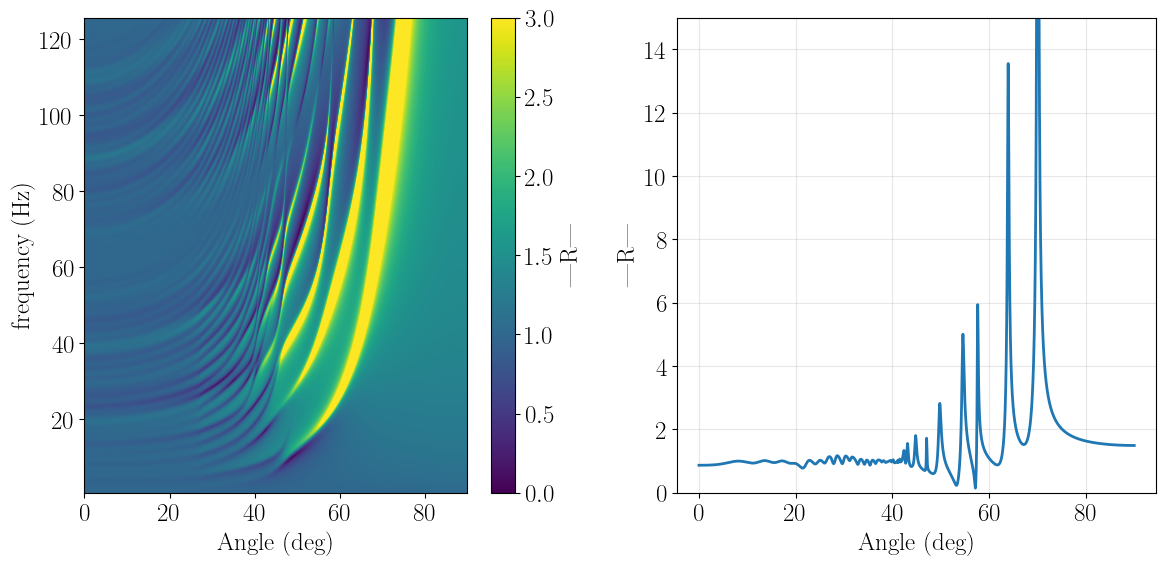

In [17]:
from src.reflectivity_kx_omega import reflectivity
from src.fortran.reflectivity_benchmark import fortran_reflectivity
import time
thetas = np.linspace(0., np.pi/2., 6*(1024-1))
omegas = 2*np.pi * np.linspace(0.1, 20, 1024) + 1.0*1j
Rmap = reflectivity(layers, omegas + 0.1*1j, thetas, 76., 76., mode="k0",  use_numba=True, fs=True) 
p = np.sin(thetas) / layers[0][1]
start = time.time()
R_f = fortran_reflectivity(layers, omegas, p, free_surface=1, zr=76., zs=76.)
end = time.time()
print(f"Fortran reflectivity elapsed time: {end-start:.2f} s")

fixed_omega = 80.
omega_idx = np.argmin(np.abs(omegas - fixed_omega))
R_at_omega = np.abs(R_f[omega_idx, :])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(np.abs(R_f), origin='lower',
            extent=[180.*thetas[0]/np.pi, 180.*thetas[-1]/np.pi, np.real(omegas[0]), np.real(omegas[-1])],
            aspect='auto',
            vmin=0, vmax=3.0)
plt.xlabel('Angle (deg)')
plt.ylabel('frequency (Hz)')
plt.colorbar(label='|R|')

plt.subplot(1,2,2)

plt.plot(180.*thetas/np.pi, R_at_omega, linewidth=2)

plt.xlabel('Angle (deg)')
plt.ylabel('|R|')
plt.grid(True, alpha=0.3)
plt.ylim([0, 15.0])
plt.tight_layout()
plt.show()

In [12]:
param.__repr__()
import numba
print(numba.threading_layer())
numba.get_num_threads()

tbb


22

In [18]:
# there is currently no loop over the number of receivers
d_cal = forward(layers, acq, param, nq_prop=2048, free_surface=True, timing=True)

Sommerfeld quadrature elapsed: 11.15 s


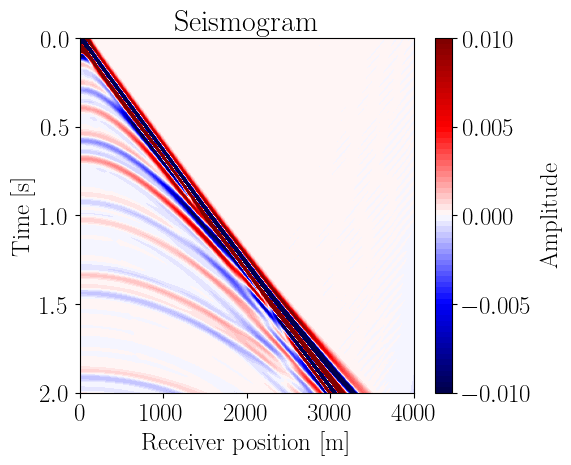

In [22]:
from src.plot.plot_tools import plot_seismogram
d_cal_seis = d_cal[0, :, :]
# [(10.0, 76.0), (250.0, 76.0), (250.0, 160.0), (580.0, 76.0), (580.0, 120.0)]
plot_seismogram(d_cal_seis.T, acq.xr, param.time, vmin=-0.01, vmax=0.01, cmap='seismic', ncolors=64, figsize=(6, 5))

In [15]:
# validation with green's function in frequency domain
rn = 6
sn = 0
freqs = np.fft.rfftfreq(param.nfft, param.dt)
omegas = 2.0 * np.pi * freqs  + 1j * 1e-12
s_t, delay = ricker_wavelet(param.time, param.freq)
print("Delay", delay)
s_w = np.conj(np.fft.rfft(np.conj(s_t), n=param.nfft)) 

Reflection = (layers[1][1] - layers[0][1])/(layers[0][1] + layers[1][1])
print("Reflection coeff:", Reflection)
vp = layers[0][1]
h = layers[0][0]
r_dist = np.sqrt( (acq.xs[sn] - acq.xr[rn])**2 + (acq.zs[sn] - acq.zr[rn])**2 )
r_travel = 2.*np.sqrt( (h-acq.zs[sn])**2 + (0.5*(acq.xs[sn] - acq.xr[rn]))**2 )
time_reflection = (2*h - 76.) / (vp) - 0.1
print("time refl", time_reflection, "seconds")

time_reflection2 = (2*h - 0.) / (vp) - 0.1
print("time refl 2 fs", time_reflection2, "seconds")

time_reflection3 = (4*h - 76.) / (vp) - 0.1
print("time refl", time_reflection3, "seconds")

print("r_dist", r_dist, "r_travel", r_travel)
T_ref = s_w*(green2d(omegas, vp, r_dist) + Reflection*green2d(omegas, vp, r_travel)) * np.exp(-1j * delay * omegas)
# T_ref *= 1j*omegas # ricker source time-derivative !
S_ref = np.conj(np.fft.irfft(np.conj(T_ref), n=param.nfft))
S_ref = S_ref[:param.nt]

plt.figure(figsize=(6,4))
plt.plot(param.time, d_cal[sn, rn, :], 'r-', label='reflectivity method')
plt.plot(param.time, S_ref, 'b--', label='green\'s kernel solution')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
#plt.ylim(-0.05, 0.05)

AttributeError: 'Parameters' object has no attribute 'freq'

In [ ]:
from src.misfit import l2_misfit
misfit = l2_misfit(d_cal[sn, rn, :], S_ref, layers=layers, acqui=acq, param=param)
print("L2 misfit between reflectivity and green's function solution:", misfit)